In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
import plotly.graph_objects as go

Bienvenido a PyMCel v0.9.10 ¡al infinito y más allá!


In [11]:
#crear un sistema de partículas de dos cuerpos con pymcel

sistema = [
    dict(m=1.0, r=np.array([0,0,0]), v=np.array([0,0,0]), ),
    dict(m=0.01, r=np.array([1,0,0]), v=np.array([0,1,0]), ) 
]

calculemos la energia total del sistema E= K+U

In [12]:
# calculemos la energia total del sistema E= K+U
K=0.5*sistema[0]['m']*np.linalg.norm(sistema[0]['v'])**2 \
    + 0.5*sistema[1]['m']*np.linalg.norm(sistema[1]['v'])**2
G=1.0
U=-G*sistema[0]['m']*sistema[1]['m']/np.linalg.norm(sistema[0]['r']- sistema[1]['r'])

In [5]:
E=K+U
E

np.float64(-0.005)

In [6]:
ts=np.linspace(0,10,100)
rs, vs, rps, vps, cuadraturas= pc.ncuerpos_solucion(sistema, ts)

Text(0.5, 0, 'x')

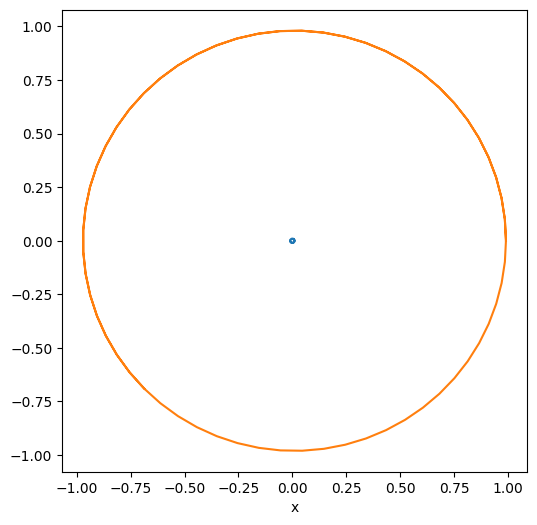

In [7]:
#graficaremos las orbitas
plt.figure(figsize=(6,6))
plt.plot(rps[0][:,0], rps[0][:,1], label='Cuerpo 1')
plt.plot(rps[1][:,0], rps[1][:,1], label='Cuerpo 2')
plt.xlabel('x') 

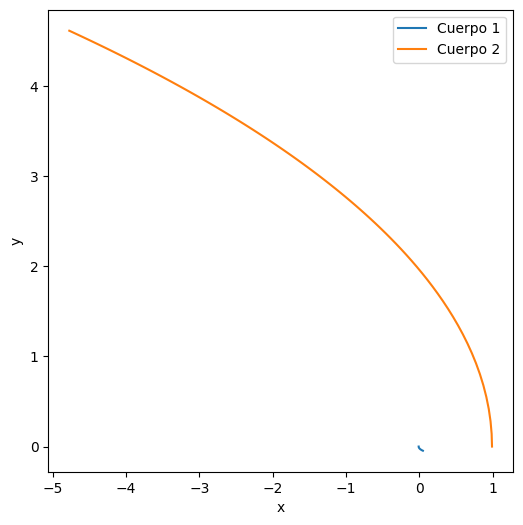

In [13]:
#repetire todo el codigo anterior pero conn velocidad np.sqrt(2*G*m/r) para que la orbita sea parabólica
sistema = [
    dict(m=1.0, r=np.array([0,0,0]), v=np.array([0,0,0]), ),
    dict(m=0.01, r=np.array([1,0,0]), v=np.array([0,np.sqrt(2*G*sistema[0]['m']/np.linalg.norm(sistema[1]['r']- sistema[0]['r'])),0]), ) 
]
ts=np.linspace(0,10,100)
rs, vs, rps, vps, cuadraturas= pc.ncuerpos_solucion(sistema, ts)
#graficaremos las orbitas
plt.figure(figsize=(6,6))
plt.plot(rps[0][:,0], rps[0][:,1], label='Cuerpo 1')
plt.plot(rps[1][:,0], rps[1][:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [17]:
#ahora quiero una grafica 3D de la órbita parabólica con plotly
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=rps[0][:,0], y=rps[0][:,1], z=rps[0][:,2], mode='lines', name='Cuerpo 1'))
fig.add_trace(go.Scatter3d(x=rps[1][:,0], y=rps[1][:,1], z=rps[1][:,2], mode='lines', name='Cuerpo 2'))
fig.update_layout(scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'), title='Órbitas de los cuerpos')
fig.show()

In [27]:
# Instala rebound en el mismo entorno del kernel y muestra errores completos
%pip install -U rebound

Note: you may need to restart the kernel to use updated packages.


In [28]:
import rebound as rb